Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Loading the dataset

In [2]:
data = pd.read_csv(r'C:\Users\user\FSDS_Adv_Gene_AI_&Agentic_AI\Machine Learning\Resume Project\Adult\adult.csv')

In [3]:
data.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [4]:
data.shape

(32561, 15)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [6]:
data.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object

In [7]:
data.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [8]:
data.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')

In [9]:
data.replace('?', np.nan, inplace = True)
data.replace('?', np.nan, inplace = True)

data.isna().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [10]:
for col in ['workclass', 'occupation', 'native.country']:
    data[col] = data[col].fillna(data[col].mode()[0])

In [11]:
data.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

# Spliting the data into X and y

In [12]:
X = data.drop('income', axis = 1)
y = data['income']

In [13]:
X

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,90,Private,77053,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States
2,66,Private,186061,Some-college,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States


In [14]:
y

0        <=50K
1        <=50K
2        <=50K
3        <=50K
4        <=50K
         ...  
32556    <=50K
32557    <=50K
32558     >50K
32559    <=50K
32560    <=50K
Name: income, Length: 32561, dtype: object

In [15]:
X = pd.get_dummies(X, drop_first = True, dtype = int) # Applying one hot encoder 
X

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,90,77053,9,0,4356,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
1,82,132870,9,0,4356,18,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
2,66,186061,10,0,4356,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
3,54,140359,4,0,3900,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
4,41,264663,10,0,3900,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,310152,10,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
32557,27,257302,12,0,0,38,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
32558,40,154374,9,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
32559,58,151910,9,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


In [16]:
from sklearn.preprocessing import LabelEncoder

label = LabelEncoder()
y = label.fit_transform(y)


In [17]:
y

array([0, 0, 0, ..., 1, 0, 0], shape=(32561,))

# split the data to train and test

In [18]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.20, random_state = 0)

In [19]:
X_train

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
15282,41,208330,10,0,0,51,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
24870,25,191921,13,0,0,25,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
18822,25,180212,9,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
26404,53,123092,9,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
7842,24,122272,13,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13123,90,282095,10,0,0,40,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
19648,36,279721,9,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
9845,26,51961,8,0,0,51,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
10799,44,115323,14,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


In [20]:
X_test

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
22278,56,274475,5,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
8950,19,237455,9,0,0,25,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
7838,23,125491,10,0,0,35,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
16505,37,48779,13,0,0,40,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
19140,49,423222,14,0,0,50,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7694,44,178134,15,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
10410,33,213887,9,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
1043,31,106753,11,0,1740,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
30860,41,202872,6,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


In [21]:
y_train

array([0, 0, 0, ..., 0, 1, 1], shape=(26048,))

# Feature Scaling

In [22]:
results = []

In [23]:
from sklearn.preprocessing import StandardScaler
sc= StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

**Model 1**: Logistic Regression Algorithm

In [24]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

from sklearn.metrics import accuracy_score
ac = accuracy_score(y_test, y_pred)
print(ac)

from sklearn.metrics import classification_report
cr = classification_report(y_test, y_pred)
print(cr)

bias = classifier.score(X_train, y_train)
print('Bais:', bias)
variance = classifier.score(X_test, y_test)
print('Variance:', variance)

[[4609  357]
 [ 649  898]]
0.8455396898510671
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      4966
           1       0.72      0.58      0.64      1547

    accuracy                           0.85      6513
   macro avg       0.80      0.75      0.77      6513
weighted avg       0.84      0.85      0.84      6513

Bais: 0.8528101965601965
Variance: 0.8455396898510671


In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "Train Accuracy": classifier.score(X_train, y_train),
    "Test Accuracy": classifier.score(X_test, y_test)
})

**Model 2**: KNN Classification Algorithm

In [26]:
from sklearn.neighbors import KNeighborsClassifier
classifier_knn = KNeighborsClassifier()
classifier_knn.fit(X_train, y_train)

y_pred = classifier_knn.predict(X_test)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

    
from sklearn.metrics import accuracy_score
ac = accuracy_score(y_test, y_pred)
print("Accuracy:", ac)


from sklearn.metrics import classification_report
cr = classification_report(y_test, y_pred)
print(cr)

bias = classifier_knn.score(X_train, y_train)
print("Bais:", bias)
variance = classifier_knn.score(X_test, y_test)
print("Variance:", variance)

[[4484  482]
 [ 665  882]]
Accuracy: 0.8238906801781053
              precision    recall  f1-score   support

           0       0.87      0.90      0.89      4966
           1       0.65      0.57      0.61      1547

    accuracy                           0.82      6513
   macro avg       0.76      0.74      0.75      6513
weighted avg       0.82      0.82      0.82      6513

Bais: 0.87442414004914
Variance: 0.8238906801781053


In [27]:

results.append({
    "Model": "KNN",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "Train Accuracy": classifier_knn.score(X_train, y_train),
    "Test Accuracy": classifier_knn.score(X_test, y_test)
})

**Model 3**: Support Vector Machine

In [28]:
from sklearn.svm import SVC
classifier_svm = SVC()
classifier_svm.fit(X_train, y_train)

y_pred = classifier_svm.predict(X_test)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

    
from sklearn.metrics import accuracy_score
ac = accuracy_score(y_test, y_pred)
print("Accuracy:", ac)


from sklearn.metrics import classification_report
cr = classification_report(y_test, y_pred)
print(cr)

bias = classifier_knn.score(X_train, y_train)
print("Bais:", bias)
variance = classifier_knn.score(X_test, y_test)
print("Variance:", variance)

[[4672  294]
 [ 699  848]]
Accuracy: 0.8475356978350991
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      4966
           1       0.74      0.55      0.63      1547

    accuracy                           0.85      6513
   macro avg       0.81      0.74      0.77      6513
weighted avg       0.84      0.85      0.84      6513

Bais: 0.87442414004914
Variance: 0.8238906801781053


In [29]:
results.append({
    "Model": "SVM",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "Train Accuracy": classifier_svm.score(X_train, y_train),
    "Test Accuracy": classifier_svm.score(X_test, y_test)
})

**Model 4**: Naive Bayes

In [30]:
from sklearn.preprocessing import Normalizer
from sklearn.naive_bayes import GaussianNB
classifier_GaussianNB = GaussianNB()
classifier_GaussianNB.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

    
from sklearn.metrics import accuracy_score
ac = accuracy_score(y_test, y_pred)
print("Accuracy:", ac)


from sklearn.metrics import classification_report
cr = classification_report(y_test, y_pred)
print(cr)

bias = classifier.score(X_train, y_train)
print("Bais:", bias)
variance = classifier.score(X_test, y_test)
print("Variance:", variance)

[[4609  357]
 [ 649  898]]
Accuracy: 0.8455396898510671
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      4966
           1       0.72      0.58      0.64      1547

    accuracy                           0.85      6513
   macro avg       0.80      0.75      0.77      6513
weighted avg       0.84      0.85      0.84      6513

Bais: 0.8528101965601965
Variance: 0.8455396898510671


In [31]:
results.append({
    "Model": "GaussianNB",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "Train Accuracy": classifier_GaussianNB.score(X_train, y_train),
    "Test Accuracy": classifier_GaussianNB.score(X_test, y_test)
})

In [32]:
# Comaprision Table

In [33]:
comp = pd.DataFrame(results)
comp

,Model,Accuracy,Precision,Recall,F1-Score,Train Accuracy,Test Accuracy
0,Logistic Regression,0.845540,0.715538,0.580478,0.640971,0.852810,0.845540
1,KNN,0.823891,0.646628,0.570136,0.605977,0.874424,0.823891
2,SVM,0.847536,0.742557,0.548158,0.630718,0.860258,0.847536
3,GaussianNB,0.845540,0.715538,0.580478,0.640971,0.446407,0.440350


Validation of  Logistic Regression ROC - AUC

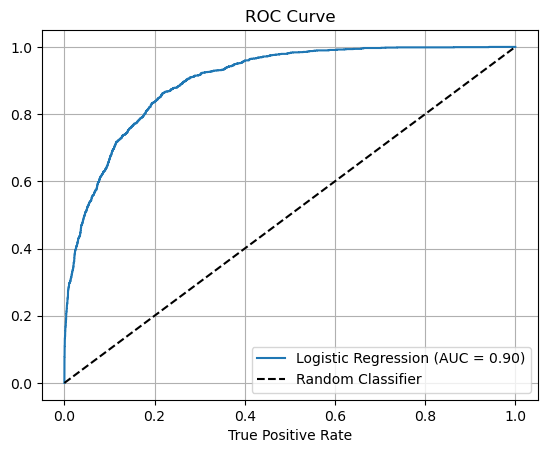

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score,roc_curve

y_prob_lr = classifier.predict_proba(X_test)[:, 1]

auc_lr = roc_auc_score(y_test, y_prob_lr)

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

plt.plot(fpr_lr, tpr_lr, label = f'Logistic Regression (AUC = {auc_lr:,.2f})')
plt.plot([0,1], [0,1], 'k--', label = 'Random Classifier')
plt.xlabel('False Positive Rate')
plt.xlabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc= 'lower right')
plt.grid()
plt.show()

# Validation of SVM ROC - AUC

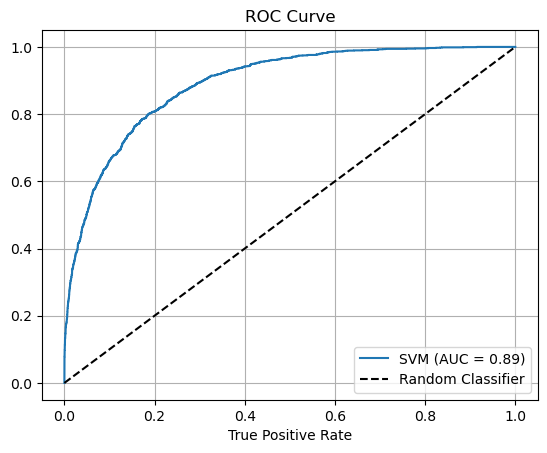

In [48]:
from sklearn.metrics import roc_auc_score,roc_curve

y_prob_svm = classifier_svm.decision_function(X_test)

auc_svm = roc_auc_score(y_test, y_prob_svm)
# print(auc_score)

auc_score = roc_auc_score(y_test, y_prob_svm)
# print(auc_score)

fpr_svm, tpr_svm, thresholds = roc_curve(y_test,y_prob_svm)

plt.plot(fpr_svm, tpr_svm, label = f'SVM (AUC = {auc_svm:,.2f})')
plt.plot([0,1], [0,1], 'k--', label = 'Random Classifier')
plt.xlabel('False Positive Rate')
plt.xlabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc = 'lower right')
plt.grid()
plt.show()

# Validation of KNN ROC - AUC

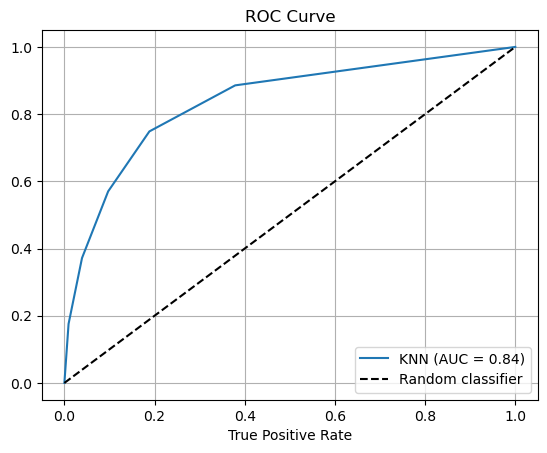

In [50]:
y_prob_knn = classifier_knn.predict_proba(X_test)[:, 1]

fpr_knn, tpr_knn, _ = roc_curve(y_test,y_prob_knn)

auc_knn = roc_auc_score(y_test, y_prob_knn)


plt.plot(fpr_knn, tpr_knn, label = f'KNN (AUC = {auc_knn:,.2f})')
plt.plot([0,1], [0,1], 'k--', label = 'Random classifier')
plt.xlabel('False Positive Rate')
plt.xlabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc= 'lower right')
plt.grid()
plt.show()

In [ ]:
Validation of GaussianNB ROC - AUC

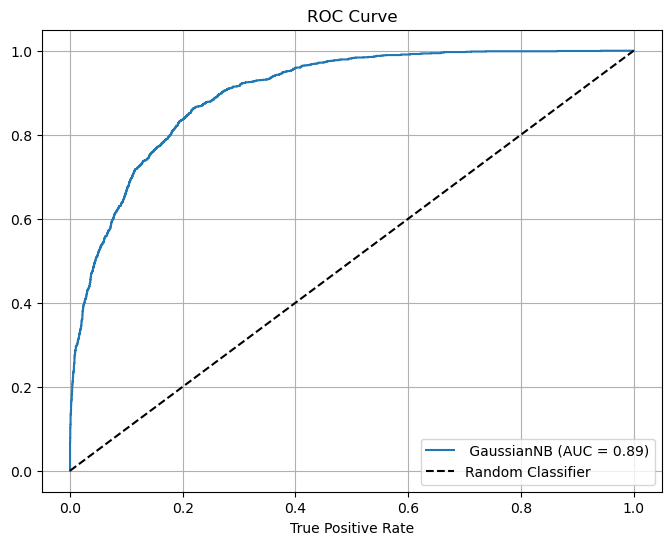

In [54]:
y_prob_GaussianNB = classifier.predict_proba(X_test)[:, 1]

auc_score_GaussianNB = roc_auc_score(y_test, y_prob_GaussianNB)

fpr, tpr, thresholds = roc_curve(y_test,y_prob_GaussianNB)

plt.figure(figsize = (8,6))
plt.plot(fpr, tpr, label = f' GaussianNB (AUC = {auc_score:,.2f})')
plt.plot([0,1], [0,1], 'k--', label = 'Random Classifier')
plt.xlabel('False Positive Rate')
plt.xlabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc= 'lower right')
plt.grid()
plt.show()

# Combining all Graph together to have more clarity and understand each Algorithm

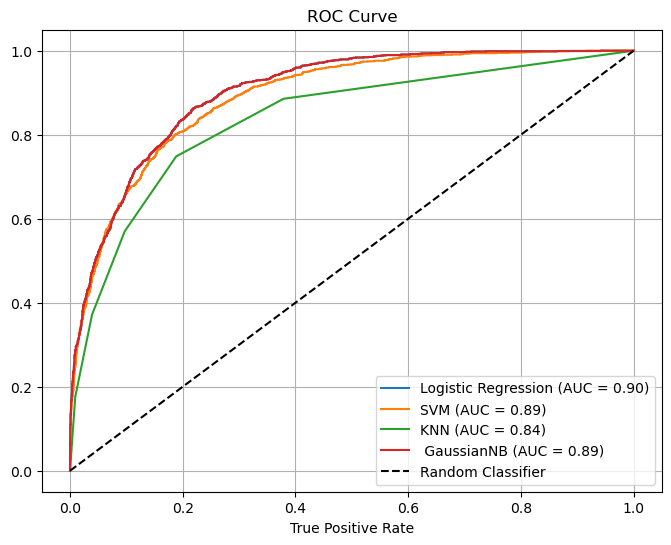

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize = (8,6))

plt.plot(fpr_lr, tpr_lr, label = f'Logistic Regression (AUC = {auc_lr:,.2f})')
plt.plot(fpr_svm, tpr_svm, label = f'SVM (AUC = {auc_svm:,.2f})')
plt.plot(fpr_knn, tpr_knn, label = f'KNN (AUC = {auc_knn:,.2f})')
plt.plot(fpr, tpr, label = f' GaussianNB (AUC = {auc_score:,.2f})')


plt.plot([0,1], [0,1], 'k--', label = 'Random Classifier')
plt.xlabel('False Positive Rate')
plt.xlabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc = 'lower right')
plt.grid()
plt.show()